In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nvitk.core as core
core.setup(globals())

import nvitk.io as io
print(core.available_backends())


('numpy', 'cupy')


In [2]:
print(np.__version__, np.__name__)

arr = np.array([1, 2, 3])
print(arr, type(arr))

with core.using('cpu'):
    arr = core.as_backend_array(arr)
    print(np.__version__, np.__name__)
    print(arr, type(arr))

arr = core.as_backend_array(arr)
print(arr, type(arr))

with core.using_backend('cpu'):
    print(np.__version__, np.__name__)
    print(arr, type(arr))



13.6.0 cupy
[1 2 3] <class 'cupy.ndarray'>
2.3.3 numpy
[1 2 3] <class 'numpy.ndarray'>
[1 2 3] <class 'cupy.ndarray'>
2.3.3 numpy
[1 2 3] <class 'cupy.ndarray'>


In [ ]:
# io.dcm2nii(
#     '/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/DATA/DICOM/202602_Week1/PESA11471769/',
#     '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/', 
#     custom_naming='AccessionNumber_Modality_SeriesNumber',
#     force_ras=True,
#     process_rtstruct=False,
#     save_metadata=False,
#     compress=True,
#     revert_scaling=True,
#     series_number=1381,
# );

ct = io.imread(
    '/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/DATA/DICOM/202602_Week1/PESA11471769/', 
    force_type='dicom',
    series_number=201,
)


Series-number header scan kept 490/2406 candidate files for series_number=1381
Selected series number: 1381
Reverting scanner scaling to obtain raw pixel values (revert_scaling takes priority over rescale_type)
Scaling factors vary across slices. Applying per-slice rescaling to 490 slices
Reverted scanner scaling on 490/490 slices to obtain raw pixel values
Forcing canonical RAS reorientation with transform:
 [[ 0. -1.]
 [ 1. -1.]
 [ 2.  1.]]
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/IA018272_PT_1381.nii.gz


In [11]:
print(ct)

Image(shape=(512, 512, 489), dtype=float64, backend=cupy, axes='XYZ', name='PESA11471769', modality='CT', submodality='Body-Low Dose CT, iDose (4)', rescale_type='DV')


In [7]:
cd = io.imread('/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_11.nii')
print(cd)
print(cd.affine)
print(cd.axes)
print(cd.backend)
print(cd.modality)
print(cd.temporal_resolution)
print(cd.dicom_tags)
print(cd.submodality)
print(cd.rescale_type)

Image(shape=(218, 256, 3, 8), dtype=float64, backend=cupy, axes='XYZT', name='Anonimo_MR_11', modality='MR', submodality='T1Map_T1_nativo_EC', rescale_type='DV')
[[ 1.29447174e+00  1.83209091e-01  1.15995789e+01 -2.55140076e+02]
 [ 5.74464738e-01  1.19154525e+00 -1.13575640e+01 -2.25932388e+02]
 [-8.28241229e-01  1.11279142e+00  1.02516098e+01 -8.69114914e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
XYZT
cupy
MR
0.275519996881485
{'ImageType': ['ORIGINAL', 'PRIMARY', 'M', 'DIS2D'], 'StudyDate': '20231107', '(0008,0020)': '20231107', 'SeriesDate': '20231107', '(0008,0021)': '20231107', 'SeriesTime': '164321.099000', '(0008,0031)': '164321.099000', 'AccessionNumber': 'Anonimo', '(0008,0050)': 'Anonimo', 'Modality': 'MR', '(0008,0060)': 'MR', 'Manufacturer': 'TROPISOFT', '(0008,0070)': 'TROPISOFT', 'SeriesDescription': 'T1Map_T1_nativo_EC', '(0008,103E)': 'T1Map_T1_nativo_EC', 'PatientID': 'PREMYO-0020-VO1-RMNc', '(0010,0020)': 'PREMYO-0020-VO1-RMNc', 'PatientS

In [9]:
io.dcm2nii(
    '/data_local/BioIT/PREMYO-0020/',
    '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/',
    custom_naming='AccessionNumber_Modality_SeriesNumber_SeriesDescription',
    force_ras=False,
    process_rtstruct=False,
    save_metadata=False,
    compress=False,
)

/home/imarcoss/miniforge3/envs/gpu-nvitk/lib/python3.11/site-packages/dicom2nifti/convert_siemens.py:285: RuntimeWarning: invalid value encountered in divide
  current_direction = current_direction / numpy.linalg.norm(current_direction)
At least 3 slices are needed for correct conversion
---------------------------------------------------------


Standard conversion with fallbacks failed: could not broadcast input array from shape (198,240,3) into shape (198,240,2)
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_3_haste_16-sl_tra_APNEA_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_37_T1Map_FFE_PF6_8(2-2)_MOCO_T1_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_33_T1Map_T1_post_hr_EC_MOCO_1.nii
Standard conversion with fallbacks failed: NOT_A_VOLUME
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_32_T1Map_T1_post_hr_EC_1.nii
Standard conversion with fallbacks failed: NOT_A_VOLUME


At least 3 slices are needed for correct conversion
---------------------------------------------------------


Standard conversion with fallbacks failed: NOT_A_VOLUME
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_11_T1Map_T1_nativo_EC_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_13_T1Map_T1_nativo_EC_MOCO_T1_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_23_DE_overview_tfl_multi-slice_EC_MAG_PSIR_1.nii
Standard conversion with fallbacks failed: NOT_A_VOLUME
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_24_DE_high-res_ec_MAG_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_17_T1Map_FFE_PF6_8(2-2)EC_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_35_T1Map_FFE_PF6_8(2-2)_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_12_T1Map_T1_nativo_EC_MOCO_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_25_DE_high-res_ec_PSIR_1.nii


At least 3 slices are needed for correct conversion
---------------------------------------------------------


...

At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------


Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_29_DE_high-res_2c_PSIR_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_22_DE_overview_tfl_multi-slice_EC_MAG_MAG_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_1019_LV_EF2_(07_11_2023_17_50_15)_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_15_T2Map_FLASH_EC_MOCO_1.nii
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_14_T2Map_FLASH_EC_1.nii


At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------
At least 3 slices are needed for correct conversion
---------------------------------------------------------


Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_34_T1Map_T1_post_hr_EC_MOCO_T1_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_2_tfl_loc_multi_iPAT_c_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_31_DE_high-res_3c_PSIR_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_26_DE_high-res_4c_MAG_1.nii
Detected TOO_FEW_SLICES/LOCALIZER error, attempting to process as single-slice or localizer...
Saved /data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_19_T1Map_FFE_PF6_8(2-2)EC_MOCO_T1_1.nii
Detected TOO_FEW_SLICES/LOCALIZE

['/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_3_haste_16-sl_tra_APNEA_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_37_T1Map_FFE_PF6_8(2-2)_MOCO_T1_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_33_T1Map_T1_post_hr_EC_MOCO_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_32_T1Map_T1_post_hr_EC_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_11_T1Map_T1_nativo_EC_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_13_T1Map_T1_nativo_EC_MOCO_T1_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_23_DE_overview_tfl_multi-slice_EC_MAG_PSIR_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_24_DE_high-res_ec_MAG_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_17_T1Map_FFE_PF6_8(2-2)EC_1.nii',
 '/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/Anonimo_MR_35_T1Map_FFE_PF6_8(2-2)_1.nii',
 '/data_local/LabVF/PESA-B

In [28]:
cd = io.imread('/data_local/LabVF/PESA-Brain/DATA/Auxiliary/plgr/R_ES03433_OP_608860030_741125729.nii')
print(cd)
print(cd.affine)
print(cd.axes)
print(cd.backend)
print(cd.modality)
print(cd.temporal_resolution)
print(cd.dicom_tags)


Image(shape=(3908, 3908, 3), dtype=uint8, backend=cupy, axes='XYZ', name='R_ES03433_OP_608860030_741125729', modality='OP')
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
XYZ
cupy
OP
None
{'ImageType': ['DERIVED', 'PRIMARY', 'CORRECTED', 'COLOR', 'WF'], '(0008,0008)': ['DERIVED', 'PRIMARY', 'CORRECTED', 'COLOR', 'WF'], 'StudyDate': '20250307', '(0008,0020)': '20250307', 'SeriesDate': '20250307', '(0008,0021)': '20250307', 'SeriesTime': '134415.847', '(0008,0031)': '134415.847', 'AccessionNumber': '', '(0008,0050)': '', 'Modality': 'OP', '(0008,0060)': 'OP', 'Manufacturer': 'Carl Zeiss Meditec', '(0008,0070)': 'Carl Zeiss Meditec', 'PatientID': 'ES03433', '(0010,0020)': 'ES03433', 'PatientSex': 'M', '(0010,0040)': 'M', 'SeriesInstanceUID': '1.2.276.0.75.2.2.70.0.2.250307134415847.30914996192.1300040', '(0020,000E)': '1.2.276.0.75.2.2.70.0.2.250307134415847.30914996192.1300040', 'InstanceNumber': 1483912570, '(0020,0013)': 1483912570, 'ImageLaterality': 'L', '(0020,0062)': 

In [ ]:
cd.metadata

{'axes': 'XYZT',
 'shape': (256, 256, 101, 15),
 'affine': array([[ 7.76844323e-01, -3.41637731e-02, -1.57620907e-02,
         -9.74834976e+01],
        [ 3.31390686e-02,  7.75496781e-01, -5.03449440e-02,
         -1.04164383e+02],
        [ 1.74291451e-02,  4.82347310e-02,  7.98258841e-01,
         -1.00079212e+01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]),
 'x_res': 0.7777461409568787,
 'y_res': 0.7777461409568787,
 'z_res': 0.8000001907348633,
 't_res': 0.005017799790948629,
 'temporal_resolution': 0.005017799790948629,
 'ImageType': ['ORIGINAL', 'PRIMARY', 'M_FFE', 'M', 'FFE'],
 '(0008,0008)': ['ORIGINAL', 'PRIMARY', 'M_FFE', 'M', 'FFE'],
 'StudyDate': '20230113',
 '(0008,0020)': '20230113',
 'SeriesDate': '20230113',
 '(0008,0021)': '20230113',
 'SeriesTime': '111223.06000',
 '(0008,0031)': '111223.06000',
 'AccessionNumber': 'BMRI607930',
 '(0008,0050)': 'BMRI607930',
 'Modality': 'MR',
 '(0008,0060)': 'MR',
 'Manufacturer': 'Philips

In [ ]:
cd = io.imread('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/RESULTS/res_GroundTruth_4DF/PESA5745609/ComplexDifference_3D.nii')
print(cd)

Image(shape=(256, 256, 101), dtype=float64, backend=cupy, axes='XYZ', name='ComplexDifference_3D', modality='MR')
[[ 7.76625156e-01 -3.32649867e-03  4.28004228e-02 -1.02754120e+02]
 [ 1.92023758e-02  7.16842294e-01 -3.09709549e-01 -8.32798920e+01]
 [-3.70636545e-02  3.01687241e-01  7.36375093e-01 -3.43766594e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
XYZ
cupy
MR
None
{'ImageType': ['ORIGINAL', 'PRIMARY', 'M_FFE', 'M', 'FFE'], '(0008,0008)': ['ORIGINAL', 'PRIMARY', 'M_FFE', 'M', 'FFE'], 'StudyDate': '20230906', '(0008,0020)': '20230906', 'SeriesDate': '20230906', '(0008,0021)': '20230906', 'SeriesTime': '134454.21000', '(0008,0031)': '134454.21000', 'AccessionNumber': 'BMRI383597', '(0008,0050)': 'BMRI383597', 'Modality': 'MR', '(0008,0060)': 'MR', 'Manufacturer': 'Philips', '(0008,0070)': 'Philips', 'PatientID': 'BMRI383597', '(0010,0020)': 'BMRI383597', 'PatientSex': '', '(0010,0040)': '', 'PatientAge': '058Y', '(0010,1010)': '058Y', 'PatientWeight': 78.0

In [4]:
print(cd.shape)
print(cd.ndim)
print(cd.dtype)
print(cd.affine)
print(cd.axes)
print(cd.metadata)
print(cd.backend)
print(cd.modality)
print(cd.is_pet)
print(cd.is_3d)
print(cd.is_4d)
print(cd.spacing)
print(cd.temporal_resolution)
print(cd.dicom_tags)
print(cd[15, 15, 15])

(256, 256, 101)
3
float64
[[ 7.76625156e-01 -3.32649867e-03  4.28004228e-02 -1.02754120e+02]
 [ 1.92023758e-02  7.16842294e-01 -3.09709549e-01 -8.32798920e+01]
 [-3.70636545e-02  3.01687241e-01  7.36375093e-01 -3.43766594e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
XYZ
{'axes': 'XYZ', 'shape': (256, 256, 101), 'affine': array([[ 7.76625156e-01, -3.32649867e-03,  4.28004228e-02,
        -1.02754120e+02],
       [ 1.92023758e-02,  7.16842294e-01, -3.09709549e-01,
        -8.32798920e+01],
       [-3.70636545e-02,  3.01687241e-01,  7.36375093e-01,
        -3.43766594e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]), 'x_res': 0.7777461409568787, 'y_res': 0.7777461409568787, 'z_res': 0.8000001311302185, 'sizeof_hdr': 348, 'extents': 0, 'session_error': 0, 'dim_info': 0, 'dim': [4, 256, 256, 101, 15, 1, 1, 1], 'intent_p1': 0.0, 'intent_p2': 0.0, 'intent_p3': 0.0, 'intent_code': 0, 'datatype': 64, 'bitpix': 64, 'slice_sta

In [5]:
tcd = io.imread('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/RESULTS/res_GroundTruth_4DF/PESA5745609/ComplexDifference_4D.nii')
print(tcd)

Image(shape=(256, 256, 101, 15), dtype=float64, backend=cupy, axes='XYZT', name='ComplexDifference_4D', modality='MR')


In [6]:
print(tcd.shape)
print(tcd.ndim)
print(tcd.dtype)
print(tcd.affine)
print(tcd.axes)
print(tcd.metadata)
print(tcd.backend)
print(tcd.modality)
print(tcd.is_pet)
print(tcd.is_3d)
print(tcd.is_4d)
print(tcd.spacing)
print(tcd.temporal_resolution)
print(tcd.dicom_tags)
print(tcd[15, 15, 15, 0])

(256, 256, 101, 15)
4
float64
[[ 7.76625156e-01 -3.32649867e-03  4.28004228e-02 -1.02754120e+02]
 [ 1.92023758e-02  7.16842294e-01 -3.09709549e-01 -8.32798920e+01]
 [-3.70636545e-02  3.01687241e-01  7.36375093e-01 -3.43766594e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
XYZT
{'axes': 'XYZT', 'shape': (256, 256, 101, 15), 'affine': array([[ 7.76625156e-01, -3.32649867e-03,  4.28004228e-02,
        -1.02754120e+02],
       [ 1.92023758e-02,  7.16842294e-01, -3.09709549e-01,
        -8.32798920e+01],
       [-3.70636545e-02,  3.01687241e-01,  7.36375093e-01,
        -3.43766594e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]), 'x_res': 0.7777461409568787, 'y_res': 0.7777461409568787, 'z_res': 0.8000001311302185, 't_res': 0.005017799790948629, 'temporal_resolution': 0.005017799790948629, 'sizeof_hdr': 348, 'extents': 0, 'session_error': 0, 'dim_info': 0, 'dim': [4, 256, 256, 101, 15, 1, 1, 1], 'intent_p1': 0.0, 'intent_

In [7]:
pet = io.imread('/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/DATA/NIFTI/202602_Week3/PESA483025/PT.nii')
print(pet)

Image(shape=(288, 288, 524), dtype=float64, backend=cupy, axes='XYZ', name='PT', modality='PT')


In [8]:
print(pet.shape)
print(pet.ndim)
print(pet.dtype)
print(pet.affine)
print(pet.axes)
print(pet.metadata)
print(pet.backend)
print(pet.modality)
print(pet.is_pet)
print(pet.is_3d)
print(pet.is_4d)
print(pet.spacing)
print(pet.temporal_resolution)
print(pet.dicom_tags)
print(pet[15, 15, 15])

(288, 288, 524)
3
float64
[[   2.           0.           0.        -286.4140625]
 [   0.           2.           0.        -356.4140625]
 [   0.           0.           2.         403.       ]
 [   0.           0.           0.           1.       ]]
XYZ
{'axes': 'XYZ', 'shape': (288, 288, 524), 'affine': array([[   2.       ,    0.       ,    0.       , -286.4140625],
       [   0.       ,    2.       ,    0.       , -356.4140625],
       [   0.       ,    0.       ,    2.       ,  403.       ],
       [   0.       ,    0.       ,    0.       ,    1.       ]]), 'x_res': 2.0, 'y_res': 2.0, 'z_res': 2.0, 'ImageType': ['ORIGINAL', 'PRIMARY'], '(0008,0008)': ['ORIGINAL', 'PRIMARY'], 'StudyDate': '20260218', '(0008,0020)': '20260218', 'SeriesDate': '20260218', '(0008,0021)': '20260218', 'SeriesTime': '100727', '(0008,0031)': '100727', 'AccessionNumber': 'IA975968', '(0008,0050)': 'IA975968', 'Modality': 'PT', '(0008,0060)': 'PT', 'Manufacturer': 'Philips', '(0008,0070)': 'Philips', 'SeriesInst

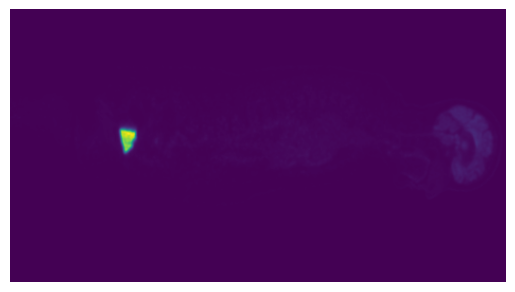

In [9]:
io.imshow(pet)